# Analiza Exploratorie a Datelor (EDA)
MovieLens Dataset

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from ml.preprocess import load_data, preprocess_movies_and_tags, build_popularity_scores

In [3]:
ratings, movies, tags, links = load_data(
    ratings_path="../data/ratings.csv",
    movies_path="../data/movies.csv",
    tags_path="../data/tags.csv",
    links_path="../data/links.csv"
)
print("Ratings:", ratings.shape)
print("Movies:", movies.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

Ratings: (100836, 3)
Movies: (9742, 3)
Tags: (3683, 3)
Links: (9742, 3)


In [4]:
print("\n--- Statistici ratings ---")
print(ratings.describe())


--- Statistici ratings ---
              userId        movieId         rating
count  100836.000000  100836.000000  100836.000000
mean      326.127564   19435.295718       3.501557
std       182.618491   35530.987199       1.042529
min         1.000000       1.000000       0.500000
25%       177.000000    1199.000000       3.000000
50%       325.000000    2991.000000       3.500000
75%       477.000000    8122.000000       4.000000
max       610.000000  193609.000000       5.000000


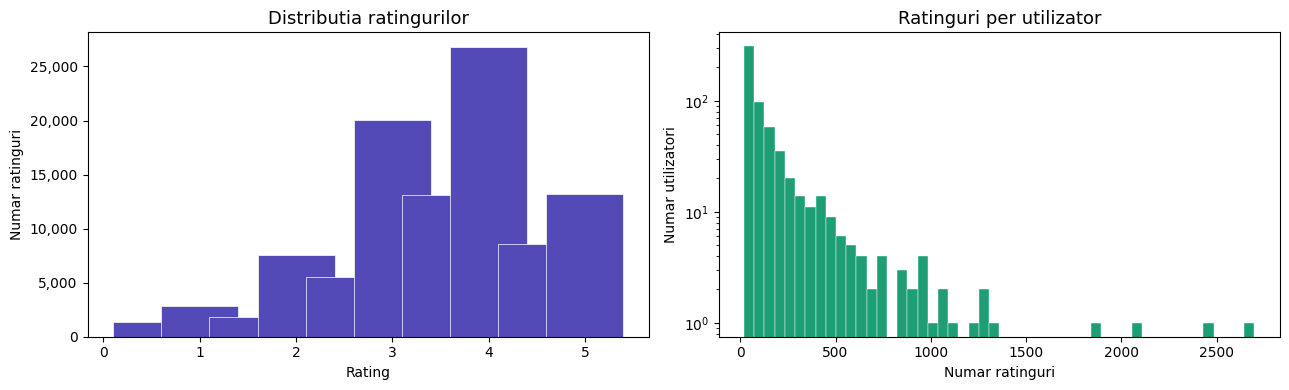

In [5]:
# Distributia ratingurilor
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = ratings["rating"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color="#534AB7", edgecolor="white", linewidth=0.5)
axes[0].set_title("Distributia ratingurilor", fontsize=13)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Numar ratinguri")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ratings_per_user = ratings.groupby("userId")["rating"].count()
axes[1].hist(ratings_per_user, bins=50, color="#1D9E75", edgecolor="white", linewidth=0.3)
axes[1].set_title("Ratinguri per utilizator", fontsize=13)
axes[1].set_xlabel("Numar ratinguri")
axes[1].set_ylabel("Numar utilizatori")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("../figures/eda_ratings_distributie.png", dpi=150, bbox_inches="tight")
plt.show()

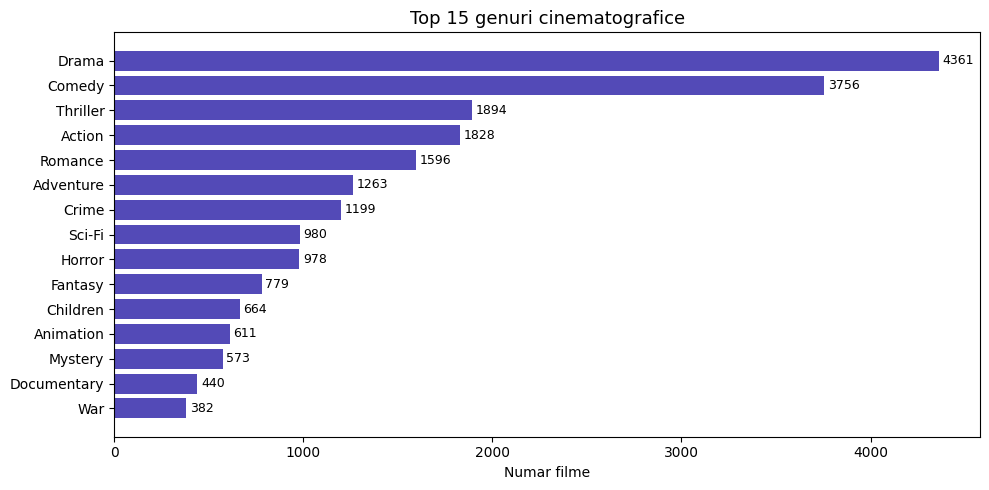

In [6]:
# Top 15 genuri
genre_counts = (
    movies["genres"].str.split("|")
    .explode()
    .value_counts()
    .drop("(no genres listed)", errors="ignore")
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color="#534AB7")
ax.set_xlabel("Numar filme")
ax.set_title("Top 15 genuri cinematografice", fontsize=13)
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/eda_genuri.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Densitatea matricei user-item
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f"Utilizatori unici : {n_users:,}")
print(f"Filme unice       : {n_movies:,}")
print(f"Total ratinguri   : {n_ratings:,}")
print(f"Sparsitate matrice: {sparsity*100:.2f}%")

Utilizatori unici : 610
Filme unice       : 9,724
Total ratinguri   : 100,836
Sparsitate matrice: 98.30%


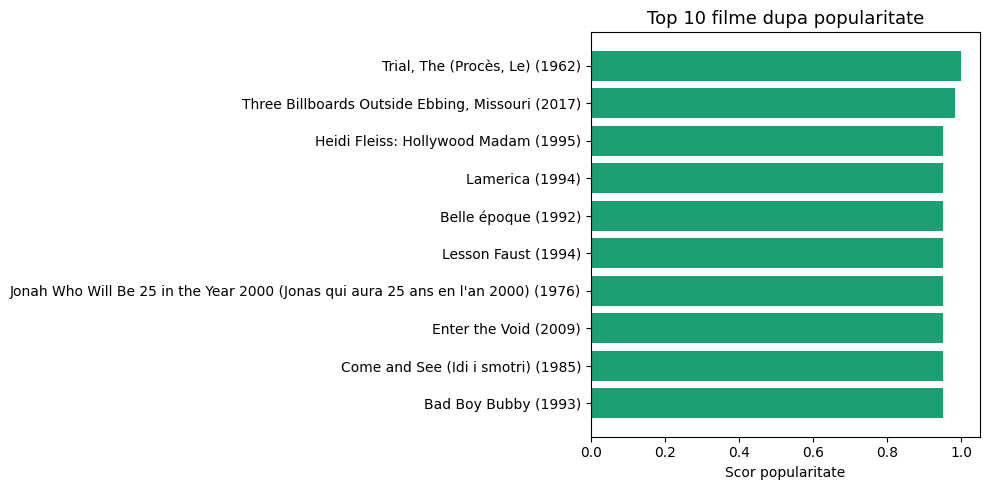

In [8]:
# Top 10 cele mai populare filme
movie_features = preprocess_movies_and_tags(movies, tags, links)
popularity_df = build_popularity_scores(ratings, movie_features)

top10 = popularity_df.sort_values("popularity_score", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10["title"][::-1], top10["popularity_score"][::-1], color="#1D9E75")
ax.set_xlabel("Scor popularitate")
ax.set_title("Top 10 filme dupa popularitate", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/eda_top_filme.png", dpi=150, bbox_inches="tight")
plt.show()